# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Objective:

Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

## Introduction

Marketing campaigns play a crucial role in banking, especially for promoting financial products such as term deposits. However, contacting all customers is inefficient and costly. Therefore, banks aim to identify customers who are more likely to subscribe to a term deposit.

This project uses the Bank Marketing dataset to analyze customer behavior and build a predictive model that can classify whether a customer will subscribe to a term deposit.

## Problem Statement

The objective of this project is to build a classification model that predicts whether a bank customer will subscribe to a term deposit based on their demographic, financial, and campaign-related information.

The target variable is:
- **y = 1** → Customer subscribes to term deposit
- **y = 0** → Customer does not subscribe

The model will help improve marketing efficiency by identifying potential customers more accurately.

## Dataset Description

The dataset used in this project is the Bank Marketing Dataset from the UCI Machine Learning Repository. It contains information related to direct marketing campaigns conducted by a bank.

Key features include:

- **age**: Age of the customer  
- **job**: Type of job  
- **marital**: Marital status  
- **education**: Education level  
- **default**: Has credit in default  
- **balance**: Average yearly balance  
- **housing**: Has housing loan  
- **loan**: Has personal loan  
- **contact**: Communication type  
- **day/month**: Last contact date  
- **duration**: Duration of last contact  
- **campaign**: Number of contacts during campaign  
- **previous**: Number of previous contacts  
- **poutcome**: Outcome of previous campaign  
- **deposit**: Target variable (subscription status)

The dataset contains multiple records of customer interactions and is used for binary classification.

## Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

## Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("bank.csv")

# Basic inspection
print("Shape:", df.shape)
df.head()

Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Understanding

In [3]:
# Column info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

## Data Preprocessing

### Encode Target Variable

In [4]:
df.columns=df.columns.str.strip()
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

### Encode Categorical Features

In [5]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## Exploratory Data Analysis (EDA)

### Target Distribution

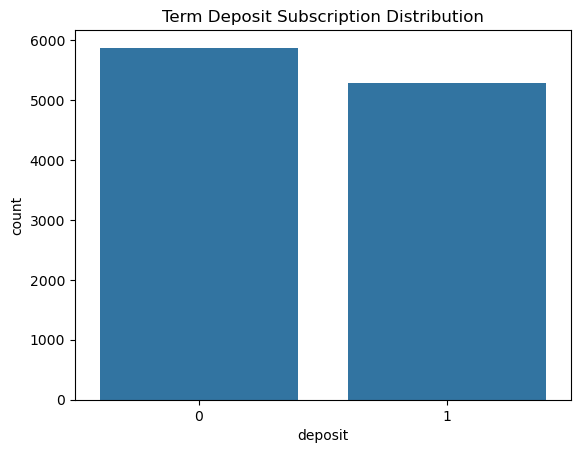

In [6]:
sns.countplot(x='deposit', data=df)
plt.title("Term Deposit Subscription Distribution")
plt.show()

### Age Distribution

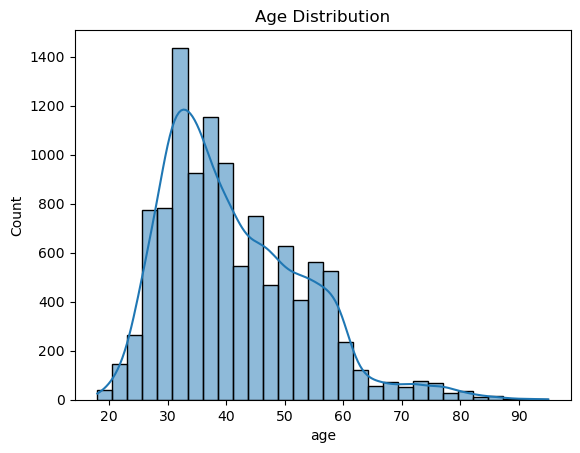

In [7]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

### Balance vs Subscription

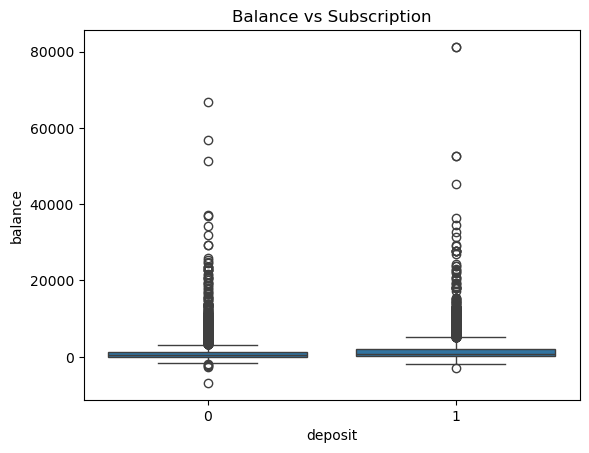

In [8]:
sns.boxplot(x='deposit', y='balance', data=df)
plt.title("Balance vs Subscription")
plt.show()

### Correlation Heatmap

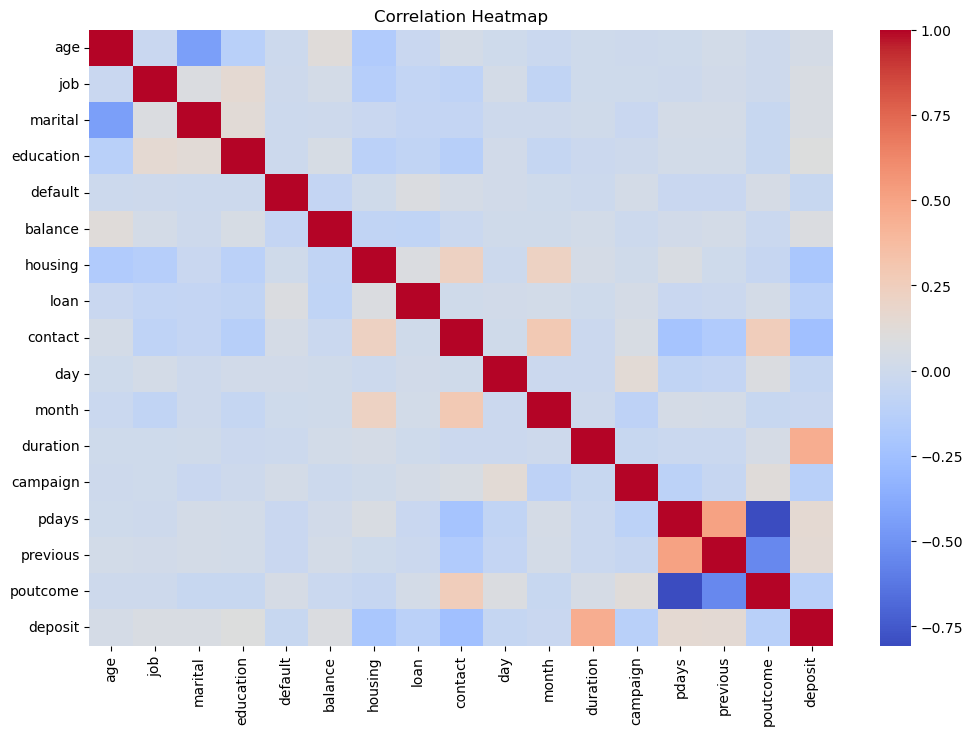

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature & Target Split

In [10]:
X = df.drop('deposit', axis=1)
y = df['deposit']

## Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Model Training
### Logistic Regression

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize the Model
log_model = LogisticRegression(solver='saga', max_iter=5000, random_state=42)

# 3. Fit (Train) on the scaled data
log_model.fit(X_train_scaled, y_train)

# 4. Predict
y_pred_log = log_model.predict(X_test_scaled)

### Random Forest

In [17]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

## Evaluation Metrics

### Logistic Regression

In [18]:
print("Logistic Regression F1 Score:",
      f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_log))

Logistic Regression F1 Score: 0.7723916532905297

Confusion Matrix:
 [[1437  305]
 [ 404 1203]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80      1742
           1       0.80      0.75      0.77      1607

    accuracy                           0.79      3349
   macro avg       0.79      0.79      0.79      3349
weighted avg       0.79      0.79      0.79      3349



### Random Forest

In [19]:
print("Random Forest F1 Score:",
      f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf))

Random Forest F1 Score: 0.8374205267938238

Confusion Matrix:
 [[1429  313]
 [ 224 1383]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1742
           1       0.82      0.86      0.84      1607

    accuracy                           0.84      3349
   macro avg       0.84      0.84      0.84      3349
weighted avg       0.84      0.84      0.84      3349



## ROC Curve

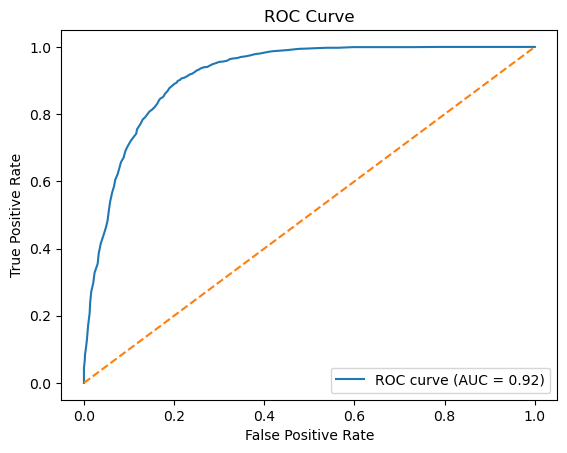

In [20]:
# Probabilities
y_prob = rf_model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Model Interpretability (SHAP)

In [23]:
!pip install shap

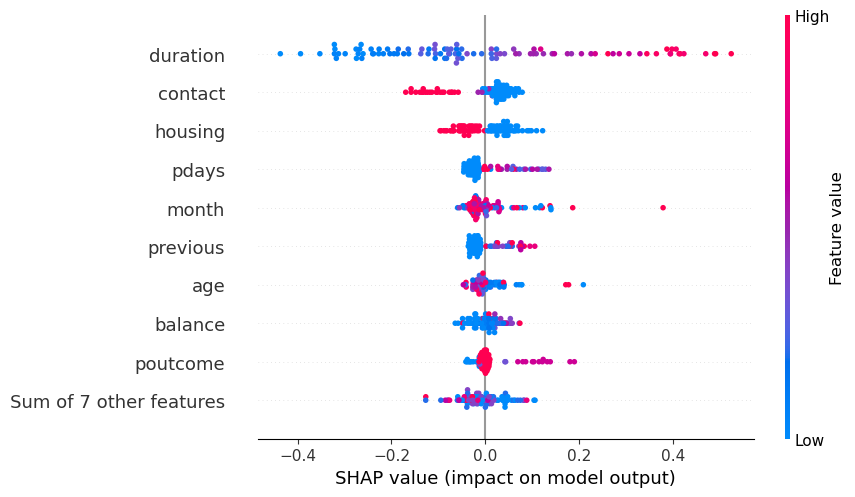

Explanation for Row 0:
Explanation for Row 1:
Explanation for Row 2:
Explanation for Row 3:
Explanation for Row 4:


In [29]:

import shap
import matplotlib.pyplot as plt

# 1. Setup Explainer and Sample
explainer = shap.TreeExplainer(rf_model)
X_sample = X_test.iloc[:100]

# 2. Use the new 'Explanation' object format (This is much more stable)
# This calculates everything and packages it correctly in one go
explanation = explainer(X_sample)

# 3. Summary Plot
# We use .values[..., 1] to get the positive class if it's a classifier
shap.plots.beeswarm(explanation[..., 1]) 

# 4. Individual Predictions (Top 5)
shap.initjs()
for i in range(5):
    print(f"Explanation for Row {i}:")
    # This uses the specific explanation object for that row
    shap.plots.force(explanation[i, ..., 1])

## Conclusion


Random Forest performed better than Logistic Regression

Campaign-related features strongly influence predictions

SHAP explains which features impact each prediction

## Model Insights


 The Random Forest model outperformed Logistic Regression by capturing non-linear relationships in the data.

- Logistic Regression provided a strong baseline with interpretable results but was limited in handling complex feature interactions.

     
- Features related to previous marketing campaigns, such as contact duration and past outcomes, had a significant impact on predictions.

     
- The model showed good performance in identifying non-subscribers, while predicting subscribers was relatively more challenging due to class imbalance.

     
- The ROC Curve and F1-score indicated that the model achieved a reasonable balance between precision and recall.

## Business Insights

 Customers who had longer interaction durations during previous campaigns are more likely to subscribe to term deposits.

     
 - Previous successful campaign outcomes significantly increase the likelihood of future subscription.

     
- Targeting customers with specific profiles (e.g., stable financial background and prior engagement) can improve marketing efficiency.


- Instead of mass marketing, banks can use predictive models to focus on high-probability customers, reducing operational costs.

    
- Data-driven targeting can enhance campaign success rates and improve return on investment (ROI).